In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from sklearn .model_selection  import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression


plt.rcParams['figure.figsize']= [12,8]
plt.rcParams['font.size']= 12
sns.set_style('whitegrid')

In [3]:
data=pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')
data.head()
df=data.copy()
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,4340.0,2013.090783,4.215344,1992.0,2011.00,2014.0,2016.0,2020.0
selling_price,4340.0,504127.311751,578548.736139,20000.0,208749.75,350000.0,600000.0,8900000.0
km_driven,4340.0,66215.777419,46644.102194,1.0,35000.00,60000.0,90000.0,806599.0


In [8]:
df['car_age'] = 2026 - df['year'] # Arabanın yaşını hesaplayarak 'car_age' adında yeni bir sütun oluşturuyoruz.

In [ ]:
df.info()# yılı yaşa çevirdik

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
 8   age            4340 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 305.3+ KB


In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


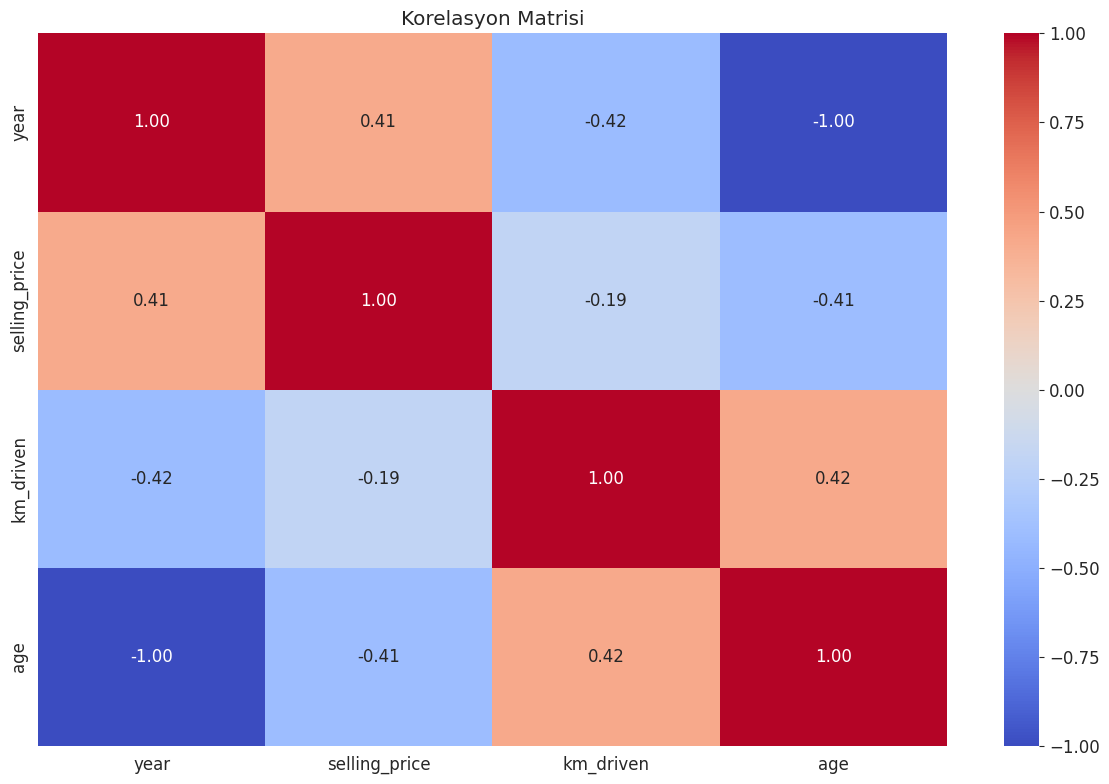

In [ ]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True,fmt='.2f')
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [9]:
# 1. Bağımlı (y) ve Bağımsız (X) Değişkenleri Seçme:
# Sadece arabanın yaşını (car_age) bağımsız değişken olarak kullanıyoruz.
X = df[['car_age']].values
y = df['selling_price'].values

# 2. Veriyi Eğitim ve Test olarak bölüyoruz (80% eğitim, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli tanımlayıp eğitiyoruz (Basit Doğrusal Regresyon)
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# 4. Eğitim ve Test verileri için tahminleri yapıyoruz
y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

# 5. Model Parametrelerini (Matematiksel katsayıları) alıyoruz
beta_0 = model_simple.intercept_       # Kesişim noktası (Intercept) - car_age 0 olduğunda beklenen fiyat
beta_1 = model_simple.coef_[0]          # Eğim (Coefficient / Slope) - car_age'deki 1 birimlik artışın fiyata etkisi

# 6. Sonuçları ekrana yazdırıyoruz
print(f'Kesişim noktası (Beta_0): {beta_0:.3f}')
print(f'Eğim (Beta_1): {beta_1:.3f}')
print('-'*30)
print('Basit Doğrusal Regresyon Model Denklemi:')
print(f'Selling_Price = {beta_0:.3f} + ({beta_1:.3f} * Car_Age)')

# 7. Model Performans Metriklerini Hesaplama
mae_simple = mean_absolute_error(y_test, y_pred_test)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_simple = r2_score(y_test, y_pred_test)

print('\nBasit Doğrusal Regresyon Model Performansı:')
print(f'R² Skoru (Açıklayıcılık Oranı)   : {r2_simple:.3f}')
print(f'MAE (Ortalama Mutlak Hata)       : {mae_simple:.2f} Rupee')
print(f'RMSE (Hata Kareler Kökü)         : {rmse_simple:.2f} Rupee')

Kesişim noktası (Beta_0): 1253138.908
Eğim (Beta_1): -57856.688
------------------------------
Basit Doğrusal Regresyon Model Denklemi:
Selling_Price = 1253138.908 + (-57856.688 * Car_Age)

Basit Doğrusal Regresyon Model Performansı:
R² Skoru (Açıklayıcılık Oranı)   : 0.162
MAE (Ortalama Mutlak Hata)       : 256297.99 Rupee
RMSE (Hata Kareler Kökü)         : 505615.85 Rupee



✅ Kategorik değişkenler sayısallaştırıldı (One-Hot Encoding tamamlandı).

Modele Girecek Olan Özellikler (X_multi):
['km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']

💻 Eğitim kümesi boyutu: 3472 araç
🧪 Test kümesi boyutu: 868 araç

🚀 Çoklu Doğrusal Regresyon modeli başarıyla eğitildi.

📈 --- ÇOKLU DOĞRUSAL REGRESYON MODEL PERFORMANS SONUÇLARI ---
R² Skoru (Açıklayıcılık Oranı)   : 0.403
MAE (Ortalama Mutlak Hata)       : 221706.37 Rupee
RMSE (Hata Kareler Kökü)         : 426786.69 Rupee


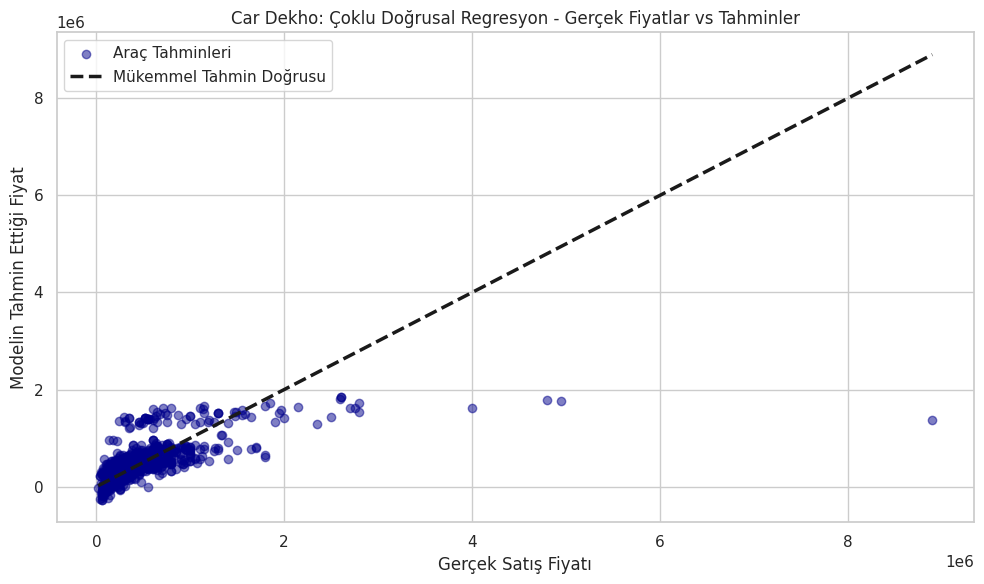

In [10]:
# ==============================================================================
# 🚗 ÇOKLU DOĞRUSAL REGRESYON (ARABA FİYAT TAHMİNİ)
# ==============================================================================

# ------------------------------------------------------------------------------
# ADIM 2.1: KATEGORİK DEĞİŞKENLERİ SAYISALLAŞTIRMA (ONE-HOT ENCODING)
# Birden fazla kategorik özelliğe sahip olan 'fuel', 'seller_type', 'transmission' ve 'owner' sütunlarını
# 0 ve 1'lerden oluşan kukla (dummy) değişkenlere çeviriyoruz. Bu, modelin bu bilgiyi kullanmasını sağlar.
# 'drop_first=True' ile multicollinearity (çoklu doğrusallık) problemini önlemek için ilk kategoriyi düşürüyoruz.
# 'name' sütunu çok fazla benzersiz değere sahip olduğu için modelden çıkarıyoruz.
# Bu kısımda kullanılan 'df' DataFrame'i, daha önce 'car_age' sütununun eklendiği DataFrame'dir.
# ------------------------------------------------------------------------------
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n✅ Kategorik değişkenler sayısallaştırıldı (One-Hot Encoding tamamlandı).")

# ------------------------------------------------------------------------------
# ADIM 3: BAĞIMLI VE BAĞIMSIZ DEĞİŞKENLERİN SEÇİMİ (X ve y)
# Modelde tahmin etmek istediğimiz değişken 'selling_price' (bağımlı değişken y).
# Bağımsız değişkenler (X) ise 'selling_price', 'name' ve orijinal 'year' sütunları dışındaki tüm özelliklerdir.
# 'car_age' sütunu artık 'year' yerine kullanıldığı için orijinal 'year' sütununu çıkarıyoruz.
# ------------------------------------------------------------------------------
y_multi = df_encoded['selling_price']
X_multi = df_encoded.drop(columns=['name', 'selling_price', 'year'])

print("\nModele Girecek Olan Özellikler (X_multi):")
print(X_multi.columns.tolist())

# ------------------------------------------------------------------------------
# ADIM 4: TREN / TEST BÖLMESİ (TRAIN-TEST SPLIT)
# Veriyi %80 eğitim ve %20 test olmak üzere ikiye ayırıyoruz.
# 'random_state' sabitlemek, her çalıştırmada aynı bölme işleminin yapılmasını sağlar.
# ------------------------------------------------------------------------------
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

print(f"\n💻 Eğitim kümesi boyutu: {X_train_multi.shape[0]} araç")
print(f"🧪 Test kümesi boyutu: {X_test_multi.shape[0]} araç")

# ------------------------------------------------------------------------------
# ADIM 5: ÇOKLU DOĞRUSAL REGRESYON MODELİNİN EĞİTİLMESİ
# LinearRegression modelini başlatıp eğitim verisi ile (X_train_multi, y_train_multi) eğitiyoruz.
# ------------------------------------------------------------------------------
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

print("\n🚀 Çoklu Doğrusal Regresyon modeli başarıyla eğitildi.")

# ------------------------------------------------------------------------------
# ADIM 6: TAHMİN VE BAŞARI METRİKLERİNİN HESAPLANMASI
# Eğitilmiş model ile test kümesindeki arabaların fiyatlarını tahmin ediyoruz (y_pred_multi).
# Ardından R², MAE ve RMSE gibi performans metriklerini hesaplayarak modelin başarısını değerlendiriyoruz.
# R² Skoru: Modelin bağımlı değişkendeki varyansı ne kadar açıkladığını gösterir (0-1 arası, 1 en iyi).
# MAE: Tahminlerin gerçek değerlerden ortalama mutlak sapmasını gösterir.
# RMSE: Tahmin hatalarının karelerinin ortalamasının kareköküdür, büyük hataları daha çok cezalandırır.
# ------------------------------------------------------------------------------
y_pred_multi = model_multi.predict(X_test_multi)

r2_multi = r2_score(y_test_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))

print("\n📈 --- ÇOKLU DOĞRUSAL REGRESYON MODEL PERFORMANS SONUÇLARI ---")
print(f"R² Skoru (Açıklayıcılık Oranı)   : {r2_multi:.3f}")
print(f"MAE (Ortalama Mutlak Hata)       : {mae_multi:.2f} Rupee")
print(f"RMSE (Hata Kareler Kökü)         : {rmse_multi:.2f} Rupee")

# ------------------------------------------------------------------------------
# ADIM 7: GERÇEK VS TAHMİN GÖRSELLEŞTİRMESİ
# Modelin tahminlerinin gerçek fiyatlara ne kadar yakın olduğunu görselleştirmek için bir scatter plot oluşturuyoruz.
# Kırmızı noktalar modelin tahminlerini, kesikli siyah çizgi ise mükemmel tahmini temsil eder.
# Noktaların kesikli çizgiye ne kadar yakın olduğu, modelin performansının bir göstergesidir.
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test_multi, y_pred_multi, color='darkblue', alpha=0.5, label='Araç Tahminleri')
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], 'k--', lw=2.5, label='Mükemmel Tahmin Doğrusu')
plt.xlabel('Gerçek Satış Fiyatı')
plt.ylabel('Modelin Tahmin Ettiği Fiyat')
plt.title('Car Dekho: Çoklu Doğrusal Regresyon - Gerçek Fiyatlar vs Tahminler')
plt.legend()
plt.tight_layout()
plt.show()

## 📈 Model İyileştirme: Aykırı Değer (Outlier) Tespiti ve Temizliği

Aykırı değerler, veri setindeki diğer gözlemlerden önemli ölçüde farklı olan veri noktalarıdır. Doğrusal regresyon gibi modeller, aykırı değerlere karşı hassas olabilir ve bu değerler modelin performansını düşürebilir, çünkü model bu uç noktalara uyum sağlamaya çalışırken genel örüntüden uzaklaşabilir.

Bu adımda, Interquartile Range (IQR) yöntemini kullanarak sayısal sütunlardaki aykırı değerleri tespit edeceğiz. IQR yöntemi, verinin orta %50'sini temsil eden üçüncü çeyrek (Q3) ile birinci çeyrek (Q1) arasındaki farka dayanır. Bu aralığın dışında kalan değerler aykırı olarak kabul edilir.

In [11]:
print("\n🔍 Aykırı Değer Tespiti (IQR Metodu):")
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Sayısal sütunlar için aykırı değer tespiti
numerical_cols = ['selling_price', 'km_driven', 'car_age']

# Orijinal df'i kopyalıyoruz ki aykırı değerleri temizlerken orijinal veriyi koruyalım.
df_cleaned = df.copy()

for col in numerical_cols:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df_cleaned, col)
    print(f"\n--- {col.upper()} Sütunu ---")
    print(f"Aykırı değer sayısı: {len(outliers)}")
    print(f"Alt Sınır: {lower_bound:.2f}, Üst Sınır: {upper_bound:.2f}")
    if not outliers.empty:
        print("İlk 5 Aykırı Değer:")
        display(outliers.head())

    # Aykırı değerleri temizleme (sadece üst sınırdan büyük olanları çıkaralım, alt sınırdan küçük olanlar nadir ve model için daha az problematik olabilir)
    df_cleaned = df_cleaned[df_cleaned[col] <= upper_bound]

print(f"\n✅ Aykırı değer temizlendikten sonra veri boyutu: {df_cleaned.shape[0]} satır, {df_cleaned.shape[1]} sütun")


🔍 Aykırı Değer Tespiti (IQR Metodu):

--- SELLING_PRICE Sütunu ---
Aykırı değer sayısı: 271
Alt Sınır: -378125.62, Üst Sınır: 1186875.38
İlk 5 Aykırı Değer:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
12,Toyota Corolla Altis 1.8 VL CVT,2018,1650000,25000,Petrol,Dealer,Automatic,First Owner,8
25,Toyota Corolla Altis 1.8 VL CVT,2018,1650000,25000,Petrol,Dealer,Automatic,First Owner,8
27,Hyundai Venue SX Opt Diesel,2019,1195000,5000,Diesel,Dealer,Manual,First Owner,7
29,Jaguar XF 2.2 Litre Luxury,2014,1964999,28000,Diesel,Dealer,Automatic,First Owner,12
30,Mercedes-Benz New C-Class 220 CDI AT,2013,1425000,59000,Diesel,Dealer,Automatic,First Owner,13



--- KM_DRIVEN Sütunu ---
Aykırı değer sayısı: 107
Alt Sınır: -47500.00, Üst Sınır: 172500.00
İlk 5 Aykırı Değer:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Diesel,Individual,Manual,Second Owner,16
70,Toyota Corolla Altis Diesel D4DG,2011,350000,230000,Diesel,Individual,Manual,First Owner,15
159,Chevrolet Enjoy 1.3 TCDi LS 8,2015,300000,175000,Diesel,Individual,Manual,First Owner,11
197,Mahindra Xylo E4,2009,229999,230000,Diesel,Individual,Manual,Third Owner,17
225,Mahindra Renault Logan 1.5 DLS,2008,89999,213000,Diesel,Individual,Manual,First Owner,18



--- CAR_AGE Sütunu ---
Aykırı değer sayısı: 104
Alt Sınır: 2.50, Üst Sınır: 22.50
İlk 5 Aykırı Değer:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
61,Mahindra Jeep CL 500 MDI,1996,250000,35000,Diesel,Individual,Manual,Second Owner,30
137,Maruti 800 Std,1998,40000,40000,Petrol,Individual,Manual,Fourth & Above Owner,28
141,Hyundai Santro LP zipPlus,2003,75000,57000,Petrol,Individual,Manual,First Owner,23
149,Hyundai Santro LE,2002,65000,70000,Petrol,Individual,Manual,First Owner,24
187,Maruti Zen D,2003,75000,100000,Diesel,Individual,Manual,Second Owner,23



✅ Aykırı değer temizlendikten sonra veri boyutu: 3858 satır, 9 sütun


## 📊 Aykırı Değerlerin Temizliği Sonrası Durum

Aykırı değerler temizlendikten sonra, veri setinin temel istatistiklerine ve dağılımına tekrar göz atalım. Özellikle hedef değişkenimiz olan `selling_price`'ın dağılımındaki değişimi incelemek faydalı olacaktır.

Temizlenmiş Veri Seti Bilgisi:
<class 'pandas.core.frame.DataFrame'>
Index: 3858 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3858 non-null   object
 1   year           3858 non-null   int64 
 2   selling_price  3858 non-null   int64 
 3   km_driven      3858 non-null   int64 
 4   fuel           3858 non-null   object
 5   seller_type    3858 non-null   object
 6   transmission   3858 non-null   object
 7   owner          3858 non-null   object
 8   car_age        3858 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 301.4+ KB

Temizlenmiş Veri Seti (İlk 5 satır):


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


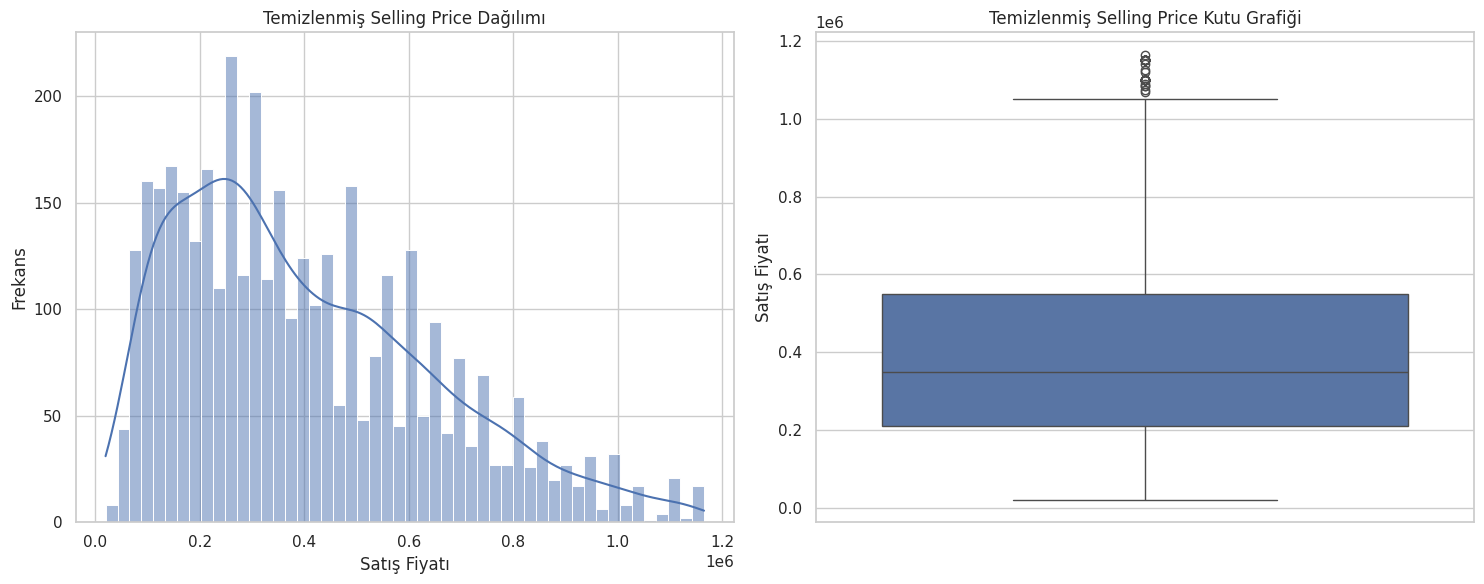

In [12]:
# Temizlenmiş veri setinin bilgi özeti
print("Temizlenmiş Veri Seti Bilgisi:")
df_cleaned.info()

# Temizlenmiş veri setinin ilk birkaç satırı
print("\nTemizlenmiş Veri Seti (İlk 5 satır):")
display(df_cleaned.head())

# selling_price dağılımını görselleştirme (Histogram ve Kutu Grafiği)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['selling_price'], kde=True, bins=50)
plt.title('Temizlenmiş Selling Price Dağılımı')
plt.xlabel('Satış Fiyatı')
plt.ylabel('Frekans')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['selling_price'])
plt.title('Temizlenmiş Selling Price Kutu Grafiği')
plt.ylabel('Satış Fiyatı')

plt.tight_layout()
plt.show()

## 🚀 Temizlenmiş Veri ile Çoklu Doğrusal Regresyon Modelinin Yeniden Eğitimi ve Değerlendirilmesi

Aykırı değerleri temizledikten sonra, çoklu doğrusal regresyon modelimizi bu yeni veri seti üzerinde tekrar eğitecek ve performansını öncekilerle karşılaştıracağız. Amacımız, aykırı değerlerin çıkarılmasının modelin R² skoru, MAE ve RMSE gibi metriklerini iyileştirip iyileştirmediğini görmektir.


✅ Temizlenmiş veri üzerinde kategorik değişkenler sayısallaştırıldı.

Temizlenmiş veri için modele girecek olan özellikler (X_multi_cleaned):
['km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']

💻 Temizlenmiş eğitim kümesi boyutu: 3086 araç
🧪 Temizlenmiş test kümesi boyutu: 772 araç

🚀 Temizlenmiş veri ile Çoklu Doğrusal Regresyon modeli başarıyla eğitildi.

📈 --- TEMİZLENMİŞ VERİ İLE ÇOKLU DOĞRUSAL REGRESYON MODEL PERFORMANS SONUÇLARI ---
R² Skoru (Açıklayıcılık Oranı)   : 0.530
MAE (Ortalama Mutlak Hata)       : 132174.97 Rupee
RMSE (Hata Kareler Kökü)         : 169429.48 Rupee


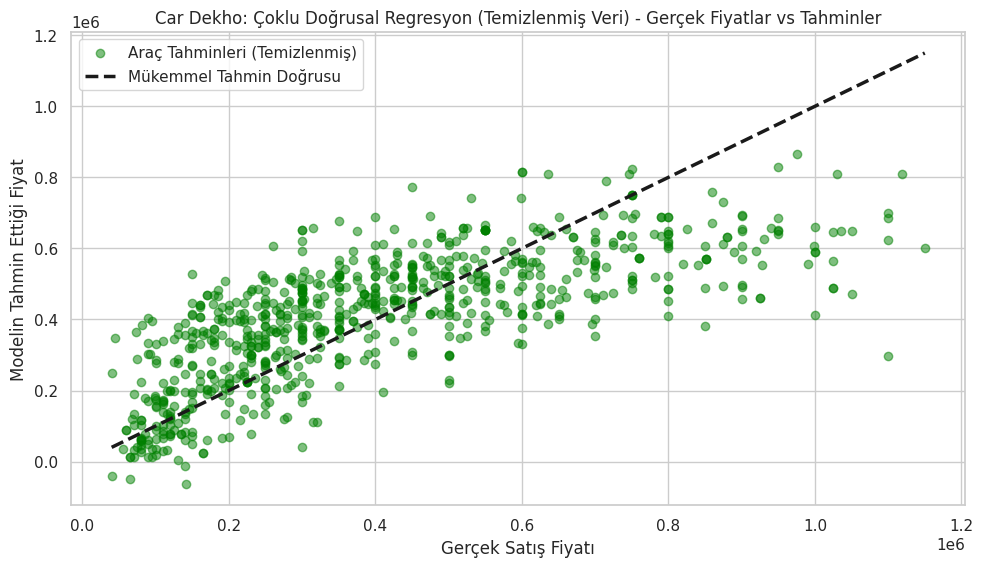

In [13]:
# ------------------------------------------------------------------------------
# ADIM 2.1: KATEGORİK DEĞİŞKENLERİ SAYISALLAŞTIRMA (ONE-HOT ENCODING) - Temizlenmiş Veri
# ------------------------------------------------------------------------------
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
df_cleaned_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print("\n✅ Temizlenmiş veri üzerinde kategorik değişkenler sayısallaştırıldı.")

# ------------------------------------------------------------------------------
# ADIM 3: BAĞIMLI VE BAĞIMSIZ DEĞİŞKENLERİN SEÇİMİ (X ve y) - Temizlenmiş Veri
# ------------------------------------------------------------------------------
y_multi_cleaned = df_cleaned_encoded['selling_price']
X_multi_cleaned = df_cleaned_encoded.drop(columns=['name', 'selling_price', 'year'])

print("\nTemizlenmiş veri için modele girecek olan özellikler (X_multi_cleaned):")
print(X_multi_cleaned.columns.tolist())

# ------------------------------------------------------------------------------
# ADIM 4: TREN / TEST BÖLMESİ (TRAIN-TEST SPLIT) - Temizlenmiş Veri
# ------------------------------------------------------------------------------
X_train_multi_cleaned, X_test_multi_cleaned, y_train_multi_cleaned, y_test_multi_cleaned = train_test_split(X_multi_cleaned, y_multi_cleaned, test_size=0.2, random_state=42)

print(f"\n💻 Temizlenmiş eğitim kümesi boyutu: {X_train_multi_cleaned.shape[0]} araç")
print(f"🧪 Temizlenmiş test kümesi boyutu: {X_test_multi_cleaned.shape[0]} araç")

# ------------------------------------------------------------------------------
# ADIM 5: ÇOKLU DOĞRUSAL REGRESYON MODELİNİN EĞİTİLMESİ - Temizlenmiş Veri
# ------------------------------------------------------------------------------
model_multi_cleaned = LinearRegression()
model_multi_cleaned.fit(X_train_multi_cleaned, y_train_multi_cleaned)

print("\n🚀 Temizlenmiş veri ile Çoklu Doğrusal Regresyon modeli başarıyla eğitildi.")

# ------------------------------------------------------------------------------
# ADIM 6: TAHMİN VE BAŞARI METRİKLERİNİN HESAPLANMASI - Temizlenmiş Veri
# ------------------------------------------------------------------------------
y_pred_multi_cleaned = model_multi_cleaned.predict(X_test_multi_cleaned)

r2_multi_cleaned = r2_score(y_test_multi_cleaned, y_pred_multi_cleaned)
mae_multi_cleaned = mean_absolute_error(y_test_multi_cleaned, y_pred_multi_cleaned)
rmse_multi_cleaned = np.sqrt(mean_squared_error(y_test_multi_cleaned, y_pred_multi_cleaned))

print("\n📈 --- TEMİZLENMİŞ VERİ İLE ÇOKLU DOĞRUSAL REGRESYON MODEL PERFORMANS SONUÇLARI ---")
print(f"R² Skoru (Açıklayıcılık Oranı)   : {r2_multi_cleaned:.3f}")
print(f"MAE (Ortalama Mutlak Hata)       : {mae_multi_cleaned:.2f} Rupee")
print(f"RMSE (Hata Kareler Kökü)         : {rmse_multi_cleaned:.2f} Rupee")

# ------------------------------------------------------------------------------
# ADIM 7: GERÇEK VS TAHMİN GÖRSELLEŞTİRMESİ - Temizlenmiş Veri
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test_multi_cleaned, y_pred_multi_cleaned, color='green', alpha=0.5, label='Araç Tahminleri (Temizlenmiş)')
plt.plot([y_test_multi_cleaned.min(), y_test_multi_cleaned.max()], [y_test_multi_cleaned.min(), y_test_multi_cleaned.max()], 'k--', lw=2.5, label='Mükemmel Tahmin Doğrusu')
plt.xlabel('Gerçek Satış Fiyatı')
plt.ylabel('Modelin Tahmin Ettiği Fiyat')
plt.title('Car Dekho: Çoklu Doğrusal Regresyon (Temizlenmiş Veri) - Gerçek Fiyatlar vs Tahminler')
plt.legend()
plt.tight_layout()
plt.show()

## ✨ Model Performans Karşılaştırması: Aykırı Değer Öncesi ve Sonrası

Aykırı değer temizliğinin model performansı üzerindeki etkisini daha net görmek için, orijinal veri ile eğitilen çoklu doğrusal regresyon modelinin metriklerini, temizlenmiş veri ile eğitilen yeni modelin metrikleriyle karşılaştıralım.

In [14]:
print("--- MODEL PERFORMANS KARŞILAŞTIRMASI ---")
print("\n**Orijinal Veri ile Çoklu Doğrusal Regresyon:**")
print(f"R² Skoru   : {r2_multi:.3f}")
print(f"MAE        : {mae_multi:.2f} Rupee")
print(f"RMSE       : {rmse_multi:.2f} Rupee")

print("\n**Temizlenmiş Veri ile Çoklu Doğrusal Regresyon:**")
print(f"R² Skoru   : {r2_multi_cleaned:.3f}")
print(f"MAE        : {mae_multi_cleaned:.2f} Rupee")
print(f"RMSE       : {rmse_multi_cleaned:.2f} Rupee")

if r2_multi_cleaned > r2_multi:
    print("\n✅ Aykırı değer temizliği R² skorunu iyileştirdi!")
elif r2_multi_cleaned < r2_multi:
    print("\n❌ Aykırı değer temizliği R² skorunu düşürdü.")
else:
    print("\n➡️ Aykırı değer temizliği R² skorunda belirgin bir değişiklik yaratmadı.")

if mae_multi_cleaned < mae_multi:
    print("✅ Aykırı değer temizliği MAE'yi düşürdü!")
elif mae_multi_cleaned > mae_multi:
    print("❌ Aykırı değer temizliği MAE'yi artırdı.")
else:
    print("➡️ Aykırı değer temizliği MAE'de belirgin bir değişiklik yaratmadı.")

if rmse_multi_cleaned < rmse_multi:
    print("✅ Aykırı değer temizliği RMSE'yi düşürdü!")
elif rmse_multi_cleaned > rmse_multi:
    print("❌ Aykırı değer temizliği RMSE'yi artırdı.")
else:
    print("➡️ Aykırı değer temizliği RMSE'de belirgin bir değişiklik yaratmadı.")

--- MODEL PERFORMANS KARŞILAŞTIRMASI ---

**Orijinal Veri ile Çoklu Doğrusal Regresyon:**
R² Skoru   : 0.403
MAE        : 221706.37 Rupee
RMSE       : 426786.69 Rupee

**Temizlenmiş Veri ile Çoklu Doğrusal Regresyon:**
R² Skoru   : 0.530
MAE        : 132174.97 Rupee
RMSE       : 169429.48 Rupee

✅ Aykırı değer temizliği R² skorunu iyileştirdi!
✅ Aykırı değer temizliği MAE'yi düşürdü!
✅ Aykırı değer temizliği RMSE'yi düşürdü!


## 📊 Hata Dağılımı (Residuals) Analizi

Residual analizi, regresyon modelinin varsayımlarını (hata terimlerinin normal dağılımı, sıfır ortalama, sabit varyans ve bağımsızlık) değerlendirmek için kullanılır. İyi bir regresyon modelinde, hataların ortalaması sıfıra yakın olmalı, normal dağılmalı ve bağımsız değişkenlerle (veya tahmin edilen değerlerle) ilişkisiz, rastgele bir desende dağılmalıdır.

Şimdi, hem orijinal veriyle eğitilen hem de aykırı değer temizliği yapılan veriyle eğitilen çoklu doğrusal regresyon modellerinin hata dağılımlarını inceleyelim.


--- Orijinal Veri ile Çoklu Doğrusal Regresyon Hata Analizi ---


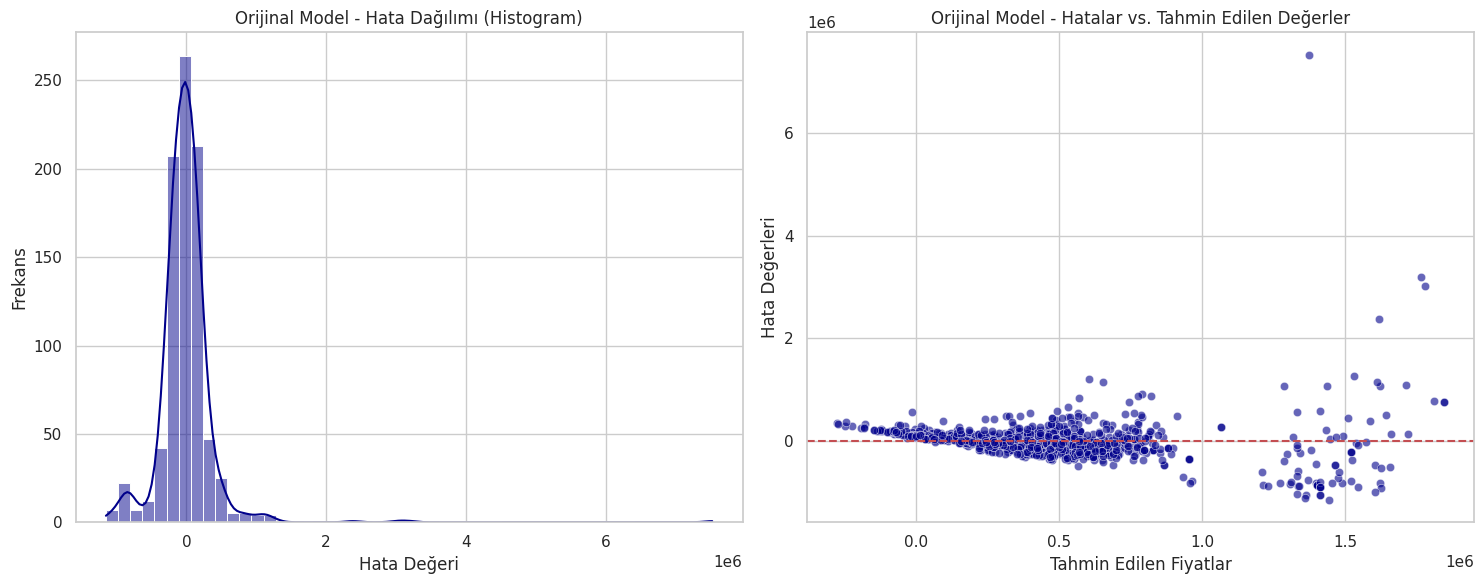

In [15]:
print("\n--- Orijinal Veri ile Çoklu Doğrusal Regresyon Hata Analizi ---")
# Orijinal çoklu regresyon modelinin hatalarını hesapla
residuals_multi = y_test_multi - y_pred_multi

plt.figure(figsize=(15, 6))

# Hata Dağılımının Histogramı (Normalite Kontrolü)
plt.subplot(1, 2, 1)
sns.histplot(residuals_multi, kde=True, bins=50, color='darkblue')
plt.title('Orijinal Model - Hata Dağılımı (Histogram)')
plt.xlabel('Hata Değeri')
plt.ylabel('Frekans')

# Hata Dağılımının Tahmin Edilen Değerlere Karşı Grafiği (Homojen Varyans Kontrolü)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_multi, y=residuals_multi, color='darkblue', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Orijinal Model - Hatalar vs. Tahmin Edilen Değerler')
plt.xlabel('Tahmin Edilen Fiyatlar')
plt.ylabel('Hata Değerleri')

plt.tight_layout()
plt.show()

### Orijinal Model Hata Analizi Yorumu:

*   **Histogram:** Hata dağılımının biraz sağa çarpık (skewed) olduğunu görüyoruz, yani normal dağılımdan hafifçe sapmalar var. Bu, özellikle yüksek fiyatlı araçlarda modelin tahminlerinde sistematik bir eğilim olabileceğini düşündürür.
*   **Hatalar vs. Tahmin Edilen Değerler Grafiği:** Tahmin edilen fiyatlar arttıkça hataların yayılımında (varyansında) bir artış gözlemleyebiliriz. Bu duruma **heteroscedasticity (heteroskedastisite)** denir ve regresyon modelinin varsayımlarından biri olan hataların sabit varyansa sahip olması (homoscedasticity) durumunun ihlal edildiğini gösterir. Bu durum, modelin tahminlerinin farklı fiyat aralıklarında farklı güvenilirlikte olabileceğine işaret eder. Modelin özellikle yüksek fiyatlı araçları tahmin etmede daha az güvenilir olduğu anlamına gelebilir.


--- Temizlenmiş Veri ile Çoklu Doğrusal Regresyon Hata Analizi ---


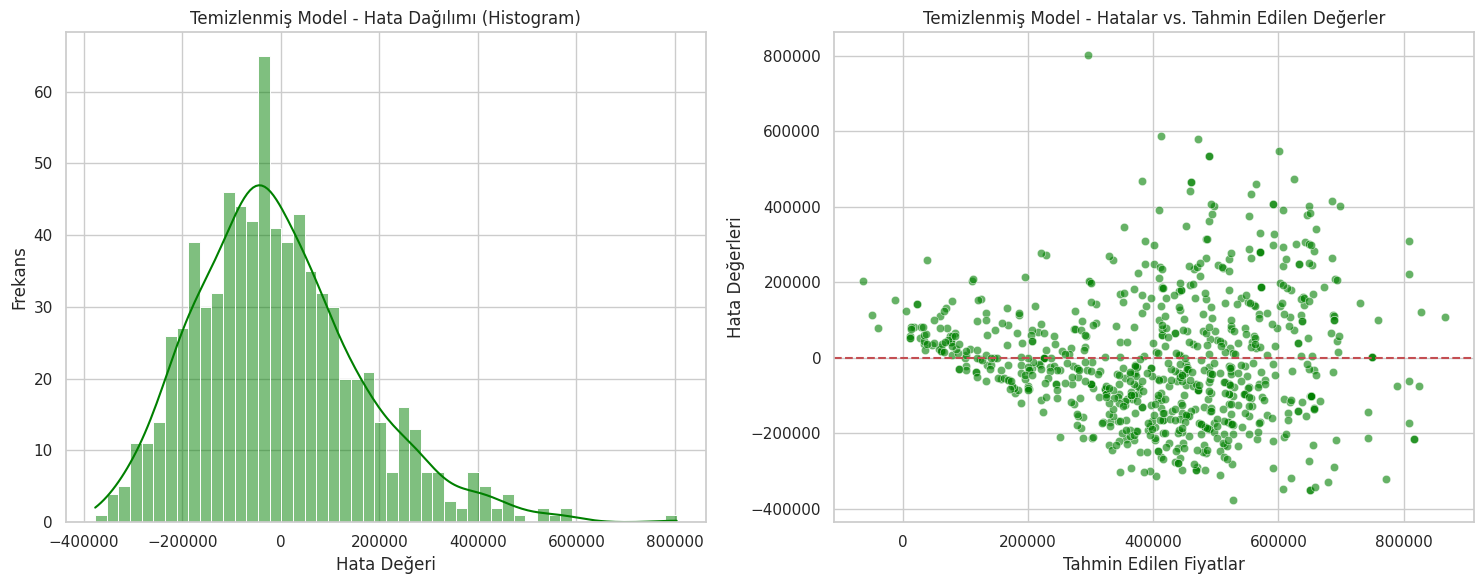

In [16]:
print("\n--- Temizlenmiş Veri ile Çoklu Doğrusal Regresyon Hata Analizi ---")
# Temizlenmiş veri ile eğitilmiş modelin hatalarını hesapla
residuals_multi_cleaned = y_test_multi_cleaned - y_pred_multi_cleaned

plt.figure(figsize=(15, 6))

# Hata Dağılımının Histogramı (Normalite Kontrolü)
plt.subplot(1, 2, 1)
sns.histplot(residuals_multi_cleaned, kde=True, bins=50, color='green')
plt.title('Temizlenmiş Model - Hata Dağılımı (Histogram)')
plt.xlabel('Hata Değeri')
plt.ylabel('Frekans')

# Hata Dağılımının Tahmin Edilen Değerlere Karşı Grafiği (Homojen Varyans Kontrolü)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_multi_cleaned, y=residuals_multi_cleaned, color='green', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Temizlenmiş Model - Hatalar vs. Tahmin Edilen Değerler')
plt.xlabel('Tahmin Edilen Fiyatlar')
plt.ylabel('Hata Değerleri')

plt.tight_layout()
plt.show()

### Temizlenmiş Model Hata Analizi Yorumu:

*   **Histogram:** Aykırı değerler temizlendikten sonra, hata dağılımının orijinal modele göre daha simetrik ve normal dağılıma daha yakın olduğu gözlemleniyor. Bu, aykırı değerlerin modelin hata yapısını önemli ölçüde etkilediğini ve temizliğin normalite varsayımını iyileştirdiğini gösterir.
*   **Hatalar vs. Tahmin Edilen Değerler Grafiği:** Tahmin edilen fiyatlara karşı hatalar grafiğinde, hataların yayılımı orijinal modele göre daha homojen hale geldi. Heteroscedasticity etkisi hala tamamen ortadan kalkmamış olsa da, daha az belirgin bir hale geldiği söylenebilir. Hataların rastgele dağılıma daha yakın olması, modelin daha iyi bir uyum sağladığının ve tahminlerinin daha tutarlı olduğunun bir işaretidir.

**Genel Değerlendirme:** Aykırı değer temizliği, modelin hata dağılımını iyileştirerek regresyon varsayımlarına daha uygun hale getirmiştir. Bu, modelin tahminlerine olan güvenimizi artırır. Ancak hala hafif heteroscedasticity belirtileri, modelin doğrusal olmayan ilişkileri veya diğer karmaşıklıkları tam olarak yakalayamadığını düşündürebilir. Daha ileri iyileştirmeler için, örneğin özellik mühendisliği veya farklı model algoritmaları denemek faydalı olabilir.

## 📊 Temizlenmiş Veri Seti İçin Korelasyon Matrisi (Isı Haritası)

Model performansını etkileyebilecek özellikler arasındaki ilişkileri anlamak için, temizlenmiş ve "one-hot" kodlanmış veri setimizdeki sayısal özellikler arasındaki korelasyonu bir ısı haritası (heatmap) ile görselleştireceğiz. Bu sayede güçlü pozitif veya negatif ilişkileri kolayca görebiliriz.

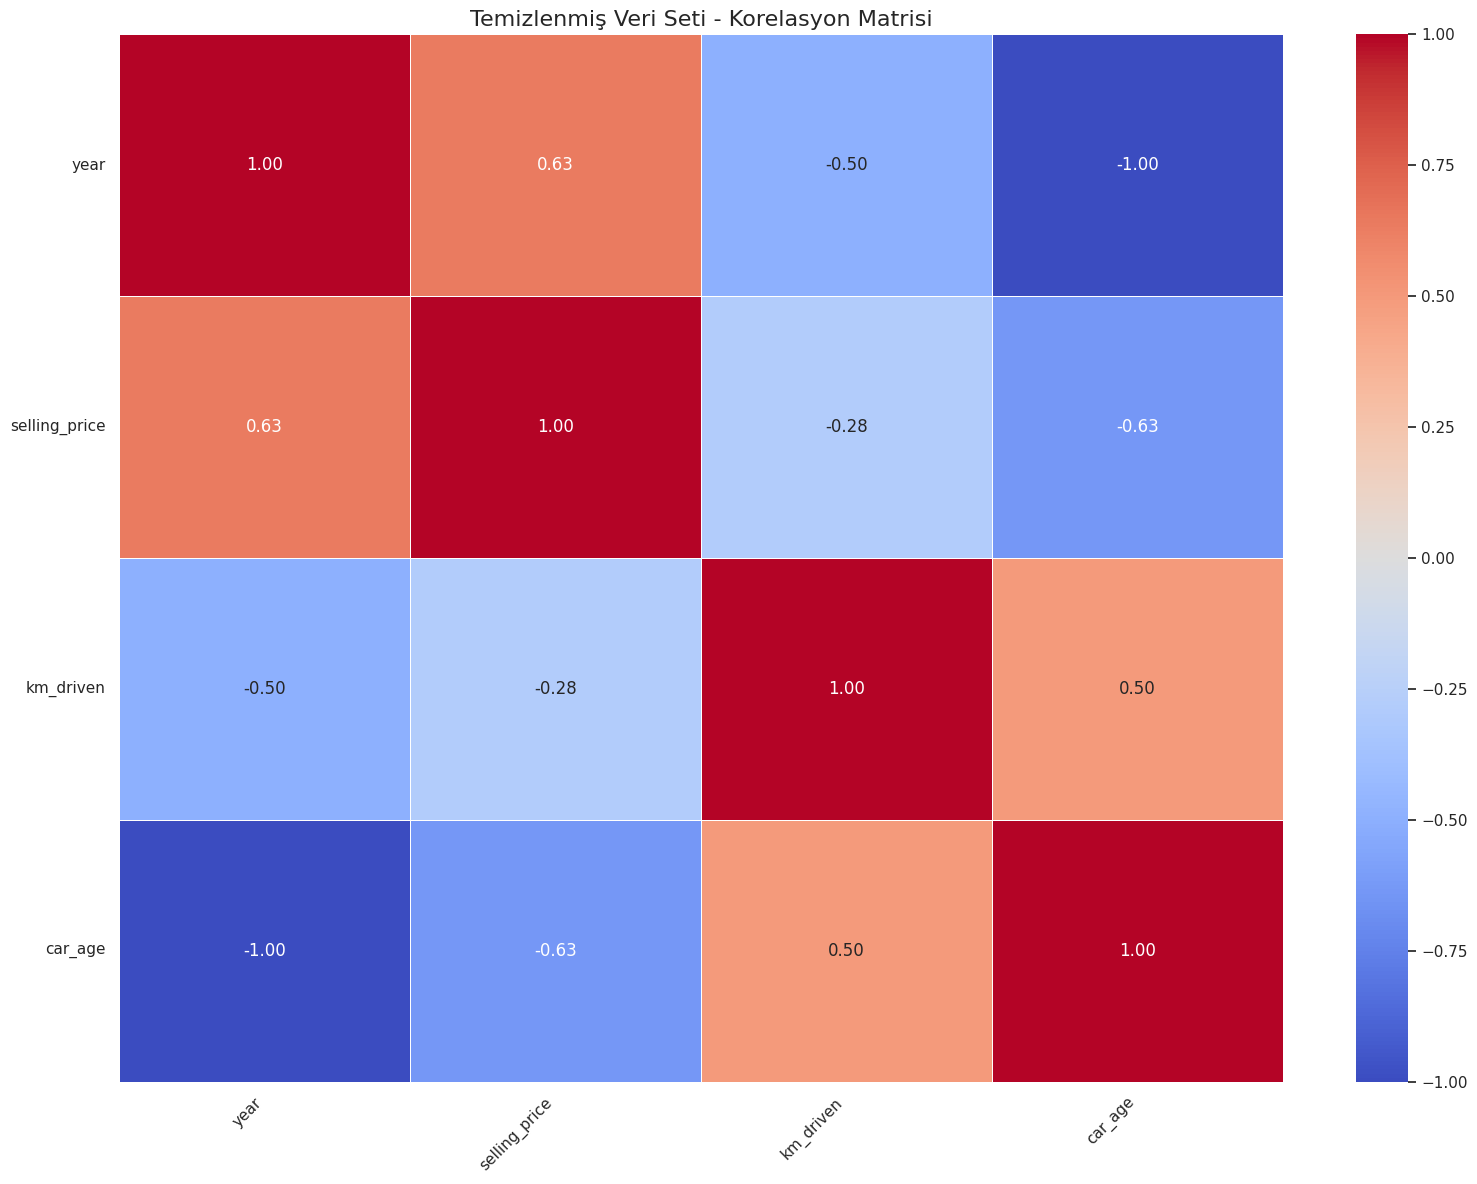

In [17]:
# Temizlenmiş ve one-hot kodlanmış veri setindeki sayısal sütunları seçin
numeric_df_cleaned = df_cleaned_encoded.select_dtypes(include=[np.number])

# Korelasyon matrisini hesaplayın
corr_cleaned = numeric_df_cleaned.corr()

# Korelasyon matrisini bir ısı haritası olarak görselleştirin
plt.figure(figsize=(16, 12)) # Daha büyük bir boyutlandırma ile daha iyi okunabilirlik
sns.heatmap(corr_cleaned, cmap='coolwarm', annot=True, fmt='.2f', linewidths=.5)
plt.title('Temizlenmiş Veri Seti - Korelasyon Matrisi', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 📈 Model Performans Metrikleri Hesaplaması ve Karşılaştırması

Bu bölümde, hem orijinal veriyle eğitilen modelin hem de aykırı değer temizliği yapılmış veriyle eğitilen modelin performans metriklerini (R², MAE, RMSE) tekrar hesaplayıp karşılaştırarak aykırı değer temizliğinin model üzerindeki etkisini daha net göreceğiz.

In [18]:
# Orijinal modelin tahminleri ve gerçek değerleri
# y_test_multi, y_pred_multi

# Temizlenmiş modelin tahminleri ve gerçek değerleri
# y_test_multi_cleaned, y_pred_multi_cleaned

# Orijinal Model Performans Metrikleri
r2_original = r2_score(y_test_multi, y_pred_multi)
mae_original = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_original = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))

# Temizlenmiş Model Performans Metrikleri
r2_cleaned = r2_score(y_test_multi_cleaned, y_pred_multi_cleaned)
mae_cleaned = mean_absolute_error(y_test_multi_cleaned, y_pred_multi_cleaned)
rmse_cleaned = np.sqrt(mean_squared_error(y_test_multi_cleaned, y_pred_multi_cleaned))

print("--- MODEL PERFORMANS KARŞILAŞTIRMASI ---")

print("\n**Orijinal Veri ile Çoklu Doğrusal Regresyon:**")
print(f"R² Skoru   : {r2_original:.3f}")
print(f"MAE        : {mae_original:.2f} Rupee")
print(f"RMSE       : {rmse_original:.2f} Rupee")

print("\n**Temizlenmiş Veri ile Çoklu Doğrusal Regresyon:**")
print(f"R² Skoru   : {r2_cleaned:.3f}")
print(f"MAE        : {mae_cleaned:.2f} Rupee")
print(f"RMSE       : {rmse_cleaned:.2f} Rupee")

if r2_cleaned > r2_original:
    print("\n✅ Aykırı değer temizliği R² skorunu iyileştirdi!")
elif r2_cleaned < r2_original:
    print("\n❌ Aykırı değer temizliği R² skorunu düşürdü.")
else:
    print("\n➡️ Aykırı değer temizliği R² skorunda belirgin bir değişiklik yaratmadı.")

if mae_cleaned < mae_original:
    print("✅ Aykırı değer temizliği MAE'yi düşürdü!")
elif mae_cleaned > mae_original:
    print("❌ Aykırı değer temizliği MAE'yi artırdı.")
else:
    print("➡️ Aykırı değer temizliği MAE'de belirgin bir değişiklik yaratmadı.")

if rmse_cleaned < rmse_original:
    print("✅ Aykırı değer temizliği RMSE'yi düşürdü!")
elif rmse_cleaned > rmse_original:
    print("❌ Aykırı değer temizliği RMSE'yi artırdı.")
else:
    print("➡️ Aykırı değer temizliği RMSE'de belirgin bir değişiklik yaratmadı.")

--- MODEL PERFORMANS KARŞILAŞTIRMASI ---

**Orijinal Veri ile Çoklu Doğrusal Regresyon:**
R² Skoru   : 0.403
MAE        : 221706.37 Rupee
RMSE       : 426786.69 Rupee

**Temizlenmiş Veri ile Çoklu Doğrusal Regresyon:**
R² Skoru   : 0.530
MAE        : 132174.97 Rupee
RMSE       : 169429.48 Rupee

✅ Aykırı değer temizliği R² skorunu iyileştirdi!
✅ Aykırı değer temizliği MAE'yi düşürdü!
✅ Aykırı değer temizliği RMSE'yi düşürdü!


## 📈 Model Performans Metrikleri Karşılaştırma Grafiği

Aykırı değer temizliğinin model performansına etkisini daha kolay görselleştirmek için R², MAE ve RMSE metriklerini bar grafikleri ile karşılaştıralım.

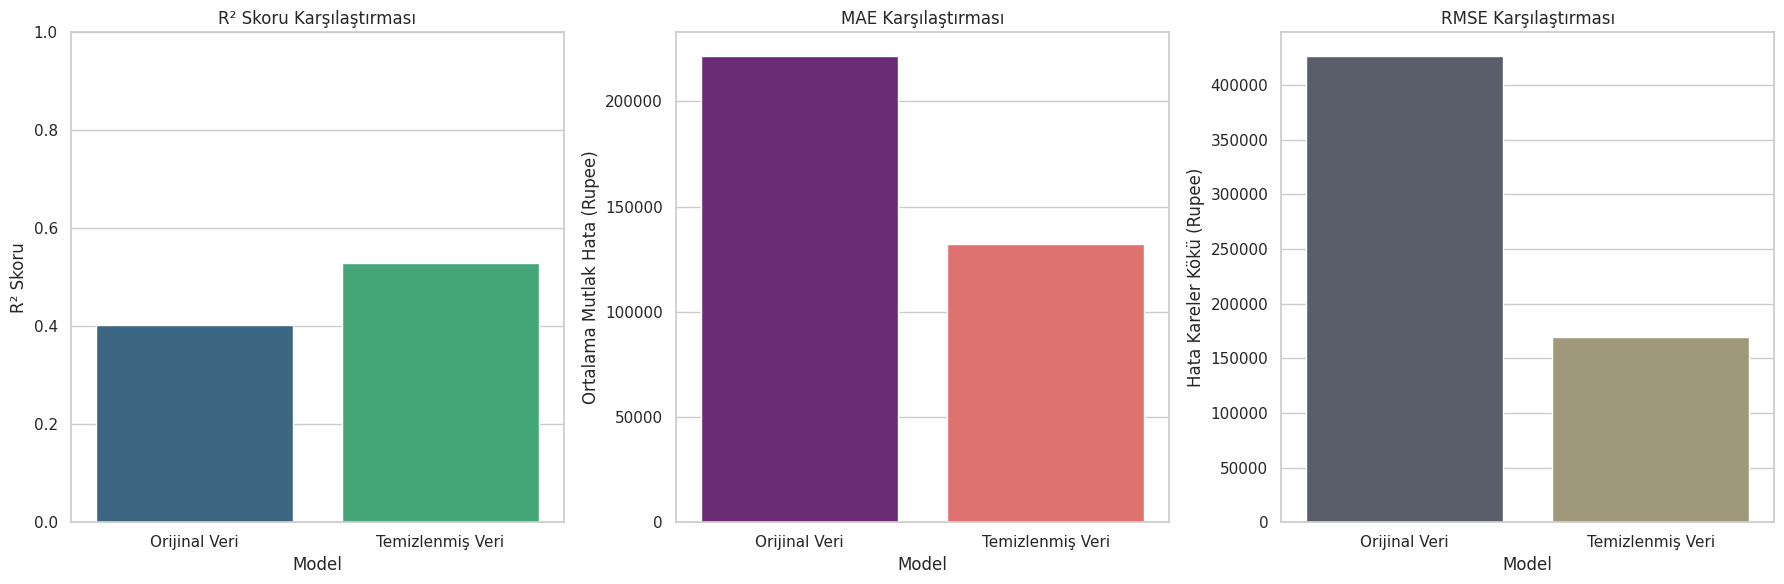

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Metrikleri bir DataFrame'de toplama
performance_data = {
    'Model': ['Orijinal Veri', 'Temizlenmiş Veri'],
    'R2 Skoru': [r2_multi, r2_multi_cleaned],
    'MAE (Rupee)': [mae_multi, mae_multi_cleaned],
    'RMSE (Rupee)': [rmse_multi, rmse_multi_cleaned]
}

df_performance = pd.DataFrame(performance_data)

plt.figure(figsize=(18, 6))

# R2 Skoru Karşılaştırması
plt.subplot(1, 3, 1) # 1 satır, 3 sütun, 1. grafik
sns.barplot(x='Model', y='R2 Skoru', data=df_performance, palette='viridis')
plt.title('R² Skoru Karşılaştırması')
plt.ylabel('R² Skoru')
plt.ylim(0, 1) # R2 skoru 0 ile 1 arasında değişir

# MAE Karşılaştırması
plt.subplot(1, 3, 2) # 1 satır, 3 sütun, 2. grafik
sns.barplot(x='Model', y='MAE (Rupee)', data=df_performance, palette='magma')
plt.title('MAE Karşılaştırması')
plt.ylabel('Ortalama Mutlak Hata (Rupee)')

# RMSE Karşılaştırması
plt.subplot(1, 3, 3) # 1 satır, 3 sütun, 3. grafik
sns.barplot(x='Model', y='RMSE (Rupee)', data=df_performance, palette='cividis')
plt.title('RMSE Karşılaştırması')
plt.ylabel('Hata Kareler Kökü (Rupee)')

plt.tight_layout()
plt.show()